# 🌐 Solution 10: HyperLPR3 (The High-Performance Community Choice)

**Category:** Lightweight Deep Learning | **Best For:** Real-time processing, diverse plate formats

Since the original OpenALPR became commercial, the community has sought high-performance, easy-to-deploy alternatives. **HyperLPR3** is one of the most popular modern open-source ALPR frameworks. It is extremely fast (designed for edge devices) and supports a wide variety of license plate formats.

### Why HyperLPR3?
- **Extremely Fast:** Optimized for CPU and mobile devices.
- **Easy Integration:** Simple Python API.
- **Robust:** Handles various lighting conditions and angles better than legacy OpenALPR.

In [ ]:
# Installation (If not already installed)
# !pip install hyperlpr3

In [1]:
import hyperlpr3 as lpr3
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

def display_image(img, title="Results"):
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

print("✅ HyperLPR3 loaded!")

✅ HyperLPR3 loaded!


## 🚗 Processing a Single Image

We'll use your test image `test/image.png` (Indian Plate).


🏁 Results for ../test/image-4.png:
  [+] Plate: WP07CB887 | Confidence: 0.96


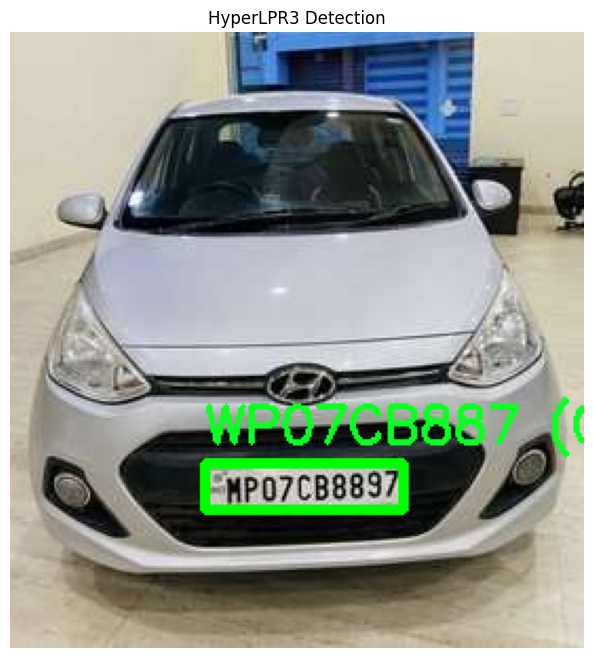

In [3]:
# Initialize HyperLPR3
catcher = lpr3.LicensePlateCatcher()

IMAGE_PATH = '../test/image-4.png'
if not os.path.exists(IMAGE_PATH):
    IMAGE_PATH = 'test/image.png'

if os.path.exists(IMAGE_PATH):
    image = cv2.imread(IMAGE_PATH)
    
    # Perform recognition using the '__call__' method
    results = catcher(image)
    
    print(f"\n🏁 Results for {IMAGE_PATH}:")
    for res in results:
        # Result format: [plate_text, confidence, type, [x, y, x2, y2]]
        plate_text = res[0]
        confidence = float(res[1])
        bbox = res[3]
        
        print(f"  [+] Plate: {plate_text} | Confidence: {confidence:.2f}")
        
        # Draw on image
        x1, y1, x2, y2 = bbox
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(image, f"{plate_text} ({confidence:.2f})", (x1, y1 - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (36, 255, 12), 2)

    display_image(image, "HyperLPR3 Detection")
else:
    print(f"❌ Image not found at {IMAGE_PATH}")

## 📂 Batch Processing

Let's see how it handles all images in the `test` directory.

In [3]:
test_dir = '../test'
if not os.path.exists(test_dir): test_dir = 'test'

if os.path.exists(test_dir):
    for filename in os.listdir(test_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            fpath = os.path.join(test_dir, filename)
            img = cv2.imread(fpath)
            results = catcher(img)
            
            plate_str = ", ".join([r[0] for r in results]) if results else "None"
            print(f"📄 {filename}: {plate_str}")
else:
    print("❌ Test directory not found.")

📄 image-1.png: GJ12CG2526
📄 image.png: GJ18805216
